<a href="https://colab.research.google.com/github/Edinson8/mineria-datos-customer-churn/blob/main/Proyecto_Mineria_Datos_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Librerías cargadas correctamente")



Librerías cargadas correctamente


In [1]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()


Filas: 7043
Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
import os

os.makedirs("resultados", exist_ok=True)

print("Carpeta creada correctamente")

Carpeta creada correctamente


In [6]:
import os

print(os.listdir())

['.config', 'resultados', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [7]:
nulos = pd.DataFrame({
    "Variable": df.columns,
    "Nulos": df.isnull().sum(),
    "Porcentaje": (df.isnull().sum()/len(df))*100
})

nulos.to_csv("resultados/tabla_nulos.csv", index=False)

nulos.head()

,Variable,Nulos,Porcentaje
customerID,customerID,0,0.0
gender,gender,0,0.0
SeniorCitizen,SeniorCitizen,0,0.0
Partner,Partner,0,0.0
Dependents,Dependents,0,0.0


In [8]:
duplicados = pd.DataFrame({
    "Cantidad_Duplicados":[df.duplicated().sum()]
})

duplicados.to_csv(
    "resultados/tabla_duplicados.csv",
    index=False
)

duplicados

,Cantidad_Duplicados
0,0


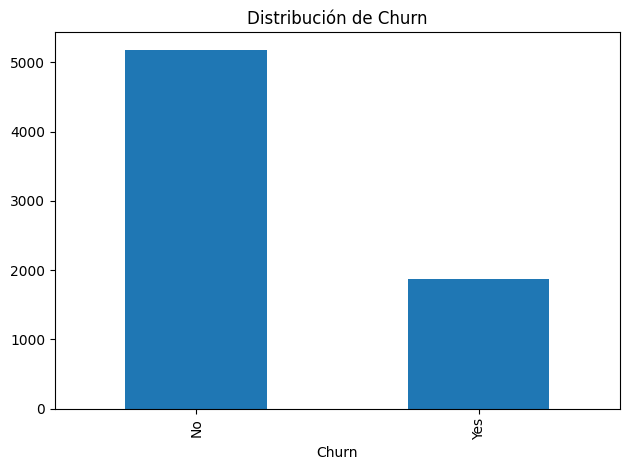

In [9]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Churn")
plt.tight_layout()

plt.savefig(
    "resultados/grafico_churn.png"
)

plt.show()

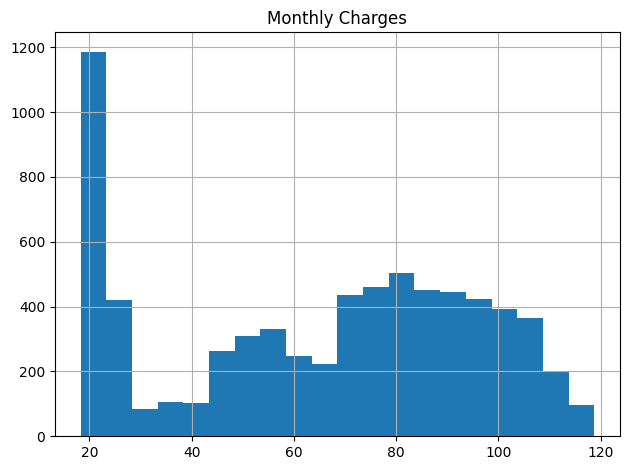

In [10]:
df["MonthlyCharges"].hist(bins=20)

plt.title("Monthly Charges")
plt.tight_layout()

plt.savefig(
    "resultados/histograma_monthlycharges.png"
)

plt.show()

In [11]:
from google.colab import files

files.download("resultados/tabla_nulos.csv")
files.download("resultados/tabla_duplicados.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
import pandas as pd
import numpy as np

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
import os
os.makedirs("resultados", exist_ok=True)

In [22]:
import pandas as pd
import numpy as np

# Ver columnas existentes
print(df.columns.tolist())

# Convertir TotalCharges a numérico
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    df["TotalCharges"] = df["TotalCharges"].fillna(
        df["TotalCharges"].median()
    )

# Eliminar customerID solo si existe
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

print("Procesamiento completado")
print(df.shape)

df.head()

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Procesamiento completado
(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

for col in df_model.columns:
    if df_model[col].dtype == "object":
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])

df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [25]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=10)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(max_depth=10, random_state=42)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

modelos = {
    "Regresion Logistica": lr,
    "Arbol Decision": dt,
    "Random Forest": rf
}

resultados = []

for nombre, modelo in modelos.items():

    pred = modelo.predict(X_test)

    resultados.append([
        nombre,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

resultados_df = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

resultados_df.to_csv(
    "resultados/resultados_modelos.csv",
    index=False
)

resultados_df

,Modelo,Accuracy,Precision,Recall,F1
0,Regresion Logistica,0.816182,0.680380,0.576408,0.624093
1,Arbol Decision,0.765791,0.557641,0.557641,0.557641
2,Random Forest,0.806246,0.676056,0.514745,0.584475


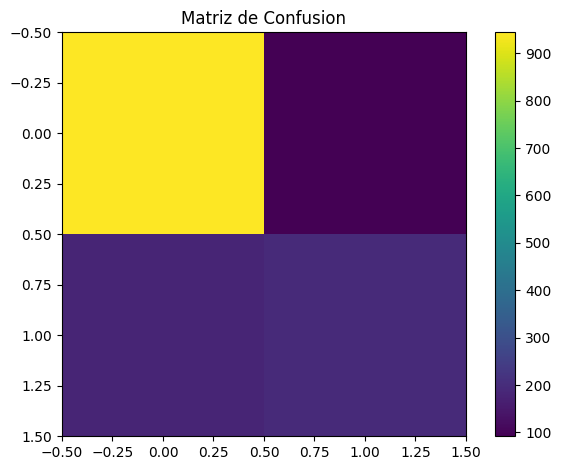

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf.predict(X_test)
)

plt.imshow(cm)

plt.title("Matriz de Confusion")

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "resultados/matriz_confusion.png"
)

plt.show()

In [29]:
import pandas as pd

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.to_csv(
    "resultados/importancia_variables.csv",
    index=False
)

importancias.head(10)

,Variable,Importancia
18,TotalCharges,0.157867
4,tenure,0.155867
17,MonthlyCharges,0.142050
14,Contract,0.132454
8,OnlineSecurity,0.078630
11,TechSupport,0.059578
16,PaymentMethod,0.042552
7,InternetService,0.040886
9,OnlineBackup,0.028231
15,PaperlessBilling,0.023494


In [30]:
from google.colab import files

files.download("resultados/resultados_modelos.csv")
files.download("resultados/importancia_variables.csv")
files.download("resultados/matriz_confusion.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>